# Chronos-2 时序预测——设备产量

使用 Amazon Chronos-2 对周度设备产量进行预测，与同目录的 Prophet 和 NeuralProphet 结果横向对比。

数据：`data/production_weekly.csv`（55行，周度，2025-03-03 ~ 2026-03-09）

训练集：前 80%（44行）；测试集：后 20%（11行）；预测步长：11周

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

In [2]:
# 加载数据并转换为 Chronos-2 长表格式
raw = pd.read_csv('data/production_weekly.csv')
raw['日期'] = pd.to_datetime(raw['日期'])

all_df = pd.DataFrame({
    'item_id':   'P',
    'timestamp': raw['日期'],
    'target':    raw['产量'].astype(float),
}).sort_values('timestamp').reset_index(drop=True)

print(f'数据行数: {len(all_df)}，时间范围: {all_df["timestamp"].min().date()} ~ {all_df["timestamp"].max().date()}')
all_df.head()

数据行数: 54，时间范围: 2025-03-03 ~ 2026-03-09


,item_id,timestamp,target
0,P,2025-03-03,76760.0
1,P,2025-03-10,77208.0
2,P,2025-03-17,73200.0
3,P,2025-03-24,76888.0
4,P,2025-03-31,69584.0


训练集: 43 行  (2025-03-03 ~ 2025-12-22)
测试集: 11 行  (2025-12-29 ~ 2026-03-09)
预测步长: 11 周


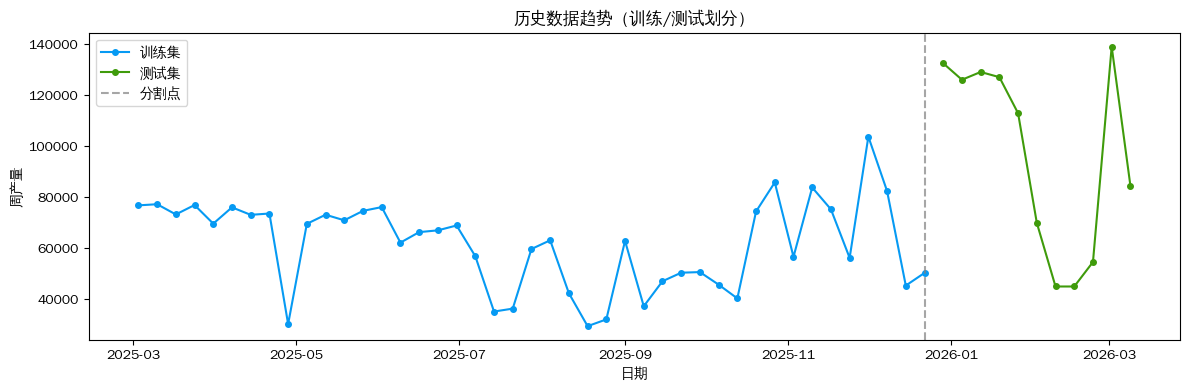

In [3]:
# 按 80/20 划分：前 80% 作为上下文，后 20% 作为测试集
TRAIN_RATIO = 0.8
split_idx  = int(len(all_df) * TRAIN_RATIO)
context_df = all_df.iloc[:split_idx].copy()
test_df    = all_df.iloc[split_idx:].copy()
PRED_LEN   = len(test_df)

print(f'训练集: {len(context_df)} 行  ({context_df["timestamp"].min().date()} ~ {context_df["timestamp"].max().date()})')
print(f'测试集: {len(test_df)} 行  ({test_df["timestamp"].min().date()} ~ {test_df["timestamp"].max().date()})')
print(f'预测步长: {PRED_LEN} 周')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pd.to_datetime(context_df['timestamp']), context_df['target'],
        marker='o', markersize=4, color='xkcd:azure', label='训练集')
ax.plot(pd.to_datetime(test_df['timestamp']),    test_df['target'],
        marker='o', markersize=4, color='xkcd:grass green', label='测试集')
ax.axvline(x=pd.to_datetime(context_df['timestamp'].iloc[-1]), color='gray', linestyle='--', alpha=0.7, label='分割点')
ax.set_title('历史数据趋势（训练/测试划分）')
ax.set_xlabel('日期')
ax.set_ylabel('周产量')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# 使用 Chronos-2 预测
pred_df = pipeline.predict_df(context_df, prediction_length=PRED_LEN, quantile_levels=[0.1, 0.5, 0.9])
print('预测结果维度:', pred_df.shape)
pred_df.head()

预测结果维度: (11, 7)


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,P,2025-12-29,target,58995.824219,34919.710938,58995.824219,83553.453125
1,P,2026-01-05,target,58805.308594,33160.871094,58805.308594,85602.609375
2,P,2026-01-12,target,60251.898438,31974.251953,60251.898438,87503.710938
3,P,2026-01-19,target,60151.320312,32848.054688,60151.320312,88616.085938
4,P,2026-01-26,target,60422.605469,31210.833984,60422.605469,89999.429688


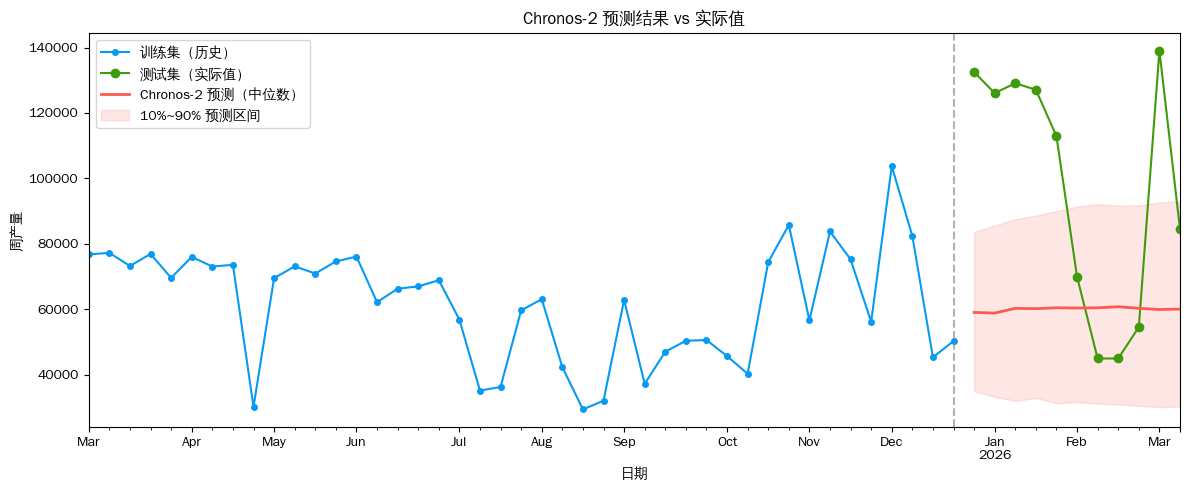

In [5]:
# 绘制预测结果 vs 实际值
item_id    = 'P'
target_col = 'target'

ts_context = context_df.set_index('timestamp')[target_col]
ts_test     = test_df.set_index('timestamp')[target_col]
ts_pred     = pred_df.query("item_id == @item_id and target_name == @target_col").set_index('timestamp')[['0.1', 'predictions', '0.9']]

ts_context.index = pd.to_datetime(ts_context.index)
ts_test.index     = pd.to_datetime(ts_test.index)

fig, ax = plt.subplots(figsize=(12, 5))
ts_context.plot(ax=ax, color='xkcd:azure', marker='o', markersize=4, label='训练集（历史）')
ts_test.plot(ax=ax,     color='xkcd:grass green', marker='o', markersize=6, label='测试集（实际值）')
ts_pred['predictions'].plot(ax=ax, color='xkcd:coral', linewidth=2, label='Chronos-2 预测（中位数）')
ax.fill_between(ts_pred.index, ts_pred['0.1'], ts_pred['0.9'],
                color='xkcd:coral', alpha=0.15, label='10%~90% 预测区间')
ax.axvline(x=ts_context.index[-1], color='gray', linestyle='--', alpha=0.6)
ax.set_title('Chronos-2 预测结果 vs 实际值')
ax.set_xlabel('日期')
ax.set_ylabel('周产量')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# 误差指标：MAE、RMSE、MAPE
y_true = ts_test.values
y_pred = ts_pred['predictions'].values

mae  = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print('─' * 35)
print(f'  MAE  (平均绝对误差):      {mae:.1f}')
print(f'  RMSE (均方根误差):        {rmse:.1f}')
print(f'  MAPE (平均绝对百分误差):  {mape:.2f}%')
print('─' * 35)

───────────────────────────────────
  MAE  (平均绝对误差):      43577.5
  RMSE (均方根误差):        51691.6
  MAPE (平均绝对百分误差):  40.11%
───────────────────────────────────
